# BASIC STATISTICS - 2

## Hospital Patient Data Analysis

In [30]:
import pandas as pd

In [31]:
patient_df = pd.read_csv("Patient_Data.csv")
billing_df = pd.read_csv("Billing_Data.csv")

In [32]:
patient_df

,PatientID,Name,Department,Doctor,BillAmount,ReceptionistID,CheckInTime
0,101,Alice,Cardiology,Dr. Smith,5000.0,1,2023-01-10 09:00
1,102,Bob,Neurology,Dr. John,NaN,2,2023-01-11 10:30
2,103,Charlie,Orthopedics,Dr. Lee,7500.0,1,2023-01-12 11:00
3,104,David,Cardiology,Dr. Smith,6200.0,3,2023-01-13 12:00
4,105,Eva,Dermatology,Dr. Rose,NaN,2,2023-01-14 08:45
5,101,Alice,Cardiology,Dr. Smith,5000.0,1,2023-01-10 09:00


In [33]:
billing_df

,PatientID,InsuranceCovered,FinalAmount
0,101,2000,3000
1,102,1500,3500
2,103,2500,5000
3,104,3000,3200
4,105,1000,4000


In [34]:
patient_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PatientID       6 non-null      int64  
 1   Name            6 non-null      str    
 2   Department      6 non-null      str    
 3   Doctor          6 non-null      str    
 4   BillAmount      4 non-null      float64
 5   ReceptionistID  6 non-null      int64  
 6   CheckInTime     6 non-null      str    
dtypes: float64(1), int64(2), str(4)
memory usage: 468.0 bytes


In [35]:
billing_columns = patient_df[['PatientID', 'Department', 'Doctor', 'BillAmount']]

billing_columns

,PatientID,Department,Doctor,BillAmount
0,101,Cardiology,Dr. Smith,5000.0
1,102,Neurology,Dr. John,NaN
2,103,Orthopedics,Dr. Lee,7500.0
3,104,Cardiology,Dr. Smith,6200.0
4,105,Dermatology,Dr. Rose,NaN
5,101,Cardiology,Dr. Smith,5000.0


In [36]:
cleaned_patient_df = patient_df.drop(
    columns=['ReceptionistID', 'CheckInTime']
)

cleaned_patient_df

,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.0
1,102,Bob,Neurology,Dr. John,NaN
2,103,Charlie,Orthopedics,Dr. Lee,7500.0
3,104,David,Cardiology,Dr. Smith,6200.0
4,105,Eva,Dermatology,Dr. Rose,NaN
5,101,Alice,Cardiology,Dr. Smith,5000.0


In [37]:
department_bill = cleaned_patient_df.groupby('Department')['BillAmount'].sum()

department_bill

Department
Cardiology     16200.0
Dermatology        0.0
Neurology          0.0
Orthopedics     7500.0
Name: BillAmount, dtype: float64

In [38]:
cleaned_patient_df.duplicated(subset='PatientID').sum()

np.int64(1)

In [39]:
cleaned_patient_df = cleaned_patient_df.drop_duplicates(
    subset='PatientID'
)

cleaned_patient_df

,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.0
1,102,Bob,Neurology,Dr. John,NaN
2,103,Charlie,Orthopedics,Dr. Lee,7500.0
3,104,David,Cardiology,Dr. Smith,6200.0
4,105,Eva,Dermatology,Dr. Rose,NaN


In [40]:
cleaned_patient_df['BillAmount'].isnull().sum()

np.int64(2)

In [41]:
mean_bill_amount = cleaned_patient_df['BillAmount'].mean()

mean_bill_amount


np.float64(6233.333333333333)

In [42]:
cleaned_patient_df['BillAmount'] = cleaned_patient_df['BillAmount'].fillna(
    mean_bill_amount
)

cleaned_patient_df

,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.000000
1,102,Bob,Neurology,Dr. John,6233.333333
2,103,Charlie,Orthopedics,Dr. Lee,7500.000000
3,104,David,Cardiology,Dr. Smith,6200.000000
4,105,Eva,Dermatology,Dr. Rose,6233.333333


In [43]:
merged_df = pd.merge(
    cleaned_patient_df,
    billing_df,
    on='PatientID',
    how='inner'
)

merged_df

,PatientID,Name,Department,Doctor,BillAmount,InsuranceCovered,FinalAmount
0,101,Alice,Cardiology,Dr. Smith,5000.000000,2000,3000
1,102,Bob,Neurology,Dr. John,6233.333333,1500,3500
2,103,Charlie,Orthopedics,Dr. Lee,7500.000000,2500,5000
3,104,David,Cardiology,Dr. Smith,6200.000000,3000,3200
4,105,Eva,Dermatology,Dr. Rose,6233.333333,1000,4000


In [44]:
new_patients = pd.DataFrame({
    'PatientID': [106, 107],
    'Name': ['Frank', 'Grace'],
    'Department': ['Neurology', 'Cardiology'],
    'Doctor': ['Dr. John', 'Dr. Smith'],
    'BillAmount': [6800, 7200],
    'InsuranceCovered': [2200, 2800],
    'FinalAmount': [4600, 4400]
})

new_patients

,PatientID,Name,Department,Doctor,BillAmount,InsuranceCovered,FinalAmount
0,106,Frank,Neurology,Dr. John,6800,2200,4600
1,107,Grace,Cardiology,Dr. Smith,7200,2800,4400


In [45]:
final_patient_df = pd.concat(
    [merged_df, new_patients],
    axis=0,
    ignore_index=True
)

final_patient_df

,PatientID,Name,Department,Doctor,BillAmount,InsuranceCovered,FinalAmount
0,101,Alice,Cardiology,Dr. Smith,5000.000000,2000,3000
1,102,Bob,Neurology,Dr. John,6233.333333,1500,3500
2,103,Charlie,Orthopedics,Dr. Lee,7500.000000,2500,5000
3,104,David,Cardiology,Dr. Smith,6200.000000,3000,3200
4,105,Eva,Dermatology,Dr. Rose,6233.333333,1000,4000
5,106,Frank,Neurology,Dr. John,6800.000000,2200,4600
6,107,Grace,Cardiology,Dr. Smith,7200.000000,2800,4400


In [46]:
patient_details = cleaned_patient_df.copy()

patient_details

,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.000000
1,102,Bob,Neurology,Dr. John,6233.333333
2,103,Charlie,Orthopedics,Dr. Lee,7500.000000
3,104,David,Cardiology,Dr. Smith,6200.000000
4,105,Eva,Dermatology,Dr. Rose,6233.333333


In [47]:
billing_categories = pd.DataFrame({
    'InsuranceCovered': [2000, 1500, 2500, 3000, 1000],
    'FinalAmount': [3000, 3500, 5000, 3200, 4000]
})

billing_categories

,InsuranceCovered,FinalAmount
0,2000,3000
1,1500,3500
2,2500,5000
3,3000,3200
4,1000,4000


In [48]:
column_wise_df = pd.concat(
    [
        patient_details.reset_index(drop=True),
        billing_categories.reset_index(drop=True)
    ],
    axis=1
)

column_wise_df

,PatientID,Name,Department,Doctor,BillAmount,InsuranceCovered,FinalAmount
0,101,Alice,Cardiology,Dr. Smith,5000.000000,2000,3000
1,102,Bob,Neurology,Dr. John,6233.333333,1500,3500
2,103,Charlie,Orthopedics,Dr. Lee,7500.000000,2500,5000
3,104,David,Cardiology,Dr. Smith,6200.000000,3000,3200
4,105,Eva,Dermatology,Dr. Rose,6233.333333,1000,4000


In [49]:
final_department_analysis = final_patient_df.groupby(
    'Department'
)['BillAmount'].sum()

final_department_analysis

Department
Cardiology     18400.000000
Dermatology     6233.333333
Neurology      13033.333333
Orthopedics     7500.000000
Name: BillAmount, dtype: float64

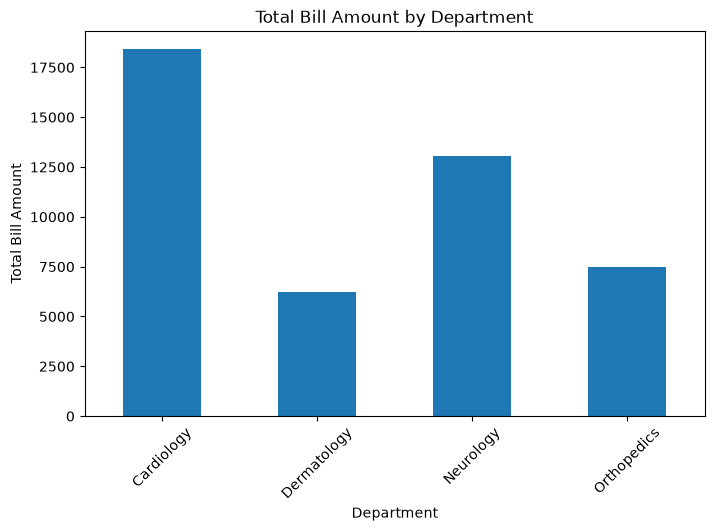

In [50]:
import matplotlib.pyplot as plt

final_department_analysis.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Total Bill Amount by Department')
plt.xlabel('Department')
plt.ylabel('Total Bill Amount')
plt.xticks(rotation=45)
plt.show()

In [51]:
final_patient_df.to_csv(
    'Final_Cleaned_Hospital_Data.csv',
    index=False
)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [52]:
final_patient_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PatientID         7 non-null      int64  
 1   Name              7 non-null      str    
 2   Department        7 non-null      str    
 3   Doctor            7 non-null      str    
 4   BillAmount        7 non-null      float64
 5   InsuranceCovered  7 non-null      int64  
 6   FinalAmount       7 non-null      int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 524.0 bytes
